*Do not delete this style setting*

In [1]:
%%html
<style>
table {float:left}
</style>

# Session 1:<br>A simple QML model in PennyLane
<table>
    <tr><td><strong>Aim:</strong></td>
        <td>To explore the process of developing a <strong>PennyLane</strong> quantum model.<br/>Watch out for modeling pits and traps!</td></tr>
    <tr><td><strong>Author:</strong></td>
        <td>Jacob L. Cybulski (<a href="https://jacobcybulski.com/" target="_blank">website</a>),
            <em>Enquanted</em></td></tr>
    <tr><td><strong>Release:</strong></td>
        <td>April 2025</td></tr>
    <tr><td><strong>Updated:</strong></td>
        <td>June 2026</td></tr>
    <tr><td><strong>Datasets:</strong></td>
        <td>Use the following two data sets (code below):<br>
            <ol><li>$y = sin(x)$</li><li>$y = sin(0.7 x+0.5\pi)$</li></ol></td></tr>
    <tr><td><strong>Tasks:</strong></td>
        <td>Time: 40 minutes (unfinished tasks go to self-directed "challenges").<br>
            All tasks listed in this table have been colour-coded across the notebook.<br>
            To make changes, you will need to hunt for the relevant section.</td></tr>
    <tr>
        <td></td>
        <td>Perform the following tasks and observe their impact on the model performance.<br>
            (Record your observations at end of this notebook):<br><ol>
            <li>Initially use <strong><em>the first dataset</em></strong> (as provided).<br>
                Follow the instructor demonstration to step through the code.</li>
            <li>Can the result improve by changing the number of epochs=50 (also use lightning qubit)</li>
            <li>Can the model work with a single qubit and single layer ?<br>
                - If yes, why? If not, why?<br><br></li>
            <li>Change the data to <strong><em>the second dataset</em></strong>, and run - observe what changed!</li>
            <li>Can the model performance be improved by trivial changes, such as:<br>
                - alter the range of model init values ? (reduce "high" for training)</li>
            <li>Can you improve the quantum model by changing the ansatz size, by:<br>
                (you may need to increase the number of epochs):<br>
                - using more qubits or more layers ? (those of you with big computers)<br>
                - using fewer qubits or fewer layers ? (those of you with tiny laptops)</li>
            <li>Change the data encoding gate from RY to RX ?<br>
                - what happens and why?<br>
                - can the performance be further improved by changing the training epochs?</li>
            <li>Change entangling from basic (R with 1 param) to strong (R with 3 params).<br>
                - what is the reason for the result ?</li><br>
                <em>The tasks below will be demonstrated by your instructor.</em><br>
                <em>However, we would like you to attempt them as challenge tasks.</em><br><br>
            <li>What should be done?</li>
            <li>Reflect on this session.</li>
        </ol></td>
    </tr>
    <tr><td><strong>References:</strong></td>
        <td><a href="https://pennylane.ai/qml/demos/tutorial_expressivity_fourier_series" target="_blank">
            Maria Schuld and Johannes Jakob Meyer, "Quantum models as Fourier series",<br>PennyLane, November 6, 2024.</a></td>
    </tr>
    <tr><td><strong>License:</strong></td>
        <td>This project is licensed under the 
            <a href="https://www.gnu.org/licenses/gpl-3.0.en.html" target="_blank">GNU General Public License v3</a></td></tr>
    <tr><td><strong>Changes:</strong></td>
        <td>All significant changes to this code must be listed at the bottom of this notebook</td></tr>
</table>

## Load the necessary packages
<font color="CornflowerBlue">Note that PennyLane redefines <strong><em>numpy</em></strong>.<br>
This is necessary to ensure that all mathematical operations are differentiable !<br>
We import "torch" even though it is not used directly, so that 'lightning.qubit' works properly on Linux systems.</font>

In [2]:
import time
import copy

import pennylane as qml
from pennylane import numpy as np
from matplotlib import pyplot as plt
import torch

%matplotlib inline

## Settings

In [3]:
n_sample = 64
n_qubits = 4
n_layers = 4 # 6 (fast computers) # 2 and 1 (slow computers)
epochs = 100 # 50 (preferred) # 100 # 300 (may take hours)
seed = 2025

np.random.seed(seed)

---

## <font color="blue">Data preparation</font>

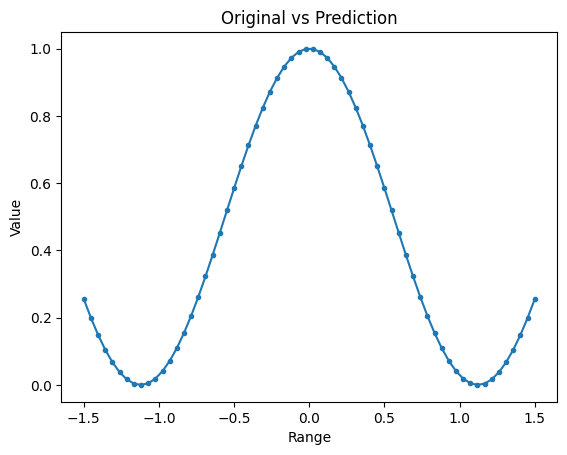

In [4]:
### Generate data set #1
# X = np.linspace(-6, 6, n_sample, requires_grad=False)
# X = X.reshape((X.shape[0], 1))
# y = np.sin(X[:,0], requires_grad=False)

### Switch to data set #2
X = np.linspace(-6, 6, n_sample, requires_grad=False)
X = X.reshape((X.shape[0], 1))
y = (np.sin(0.7*X[:,0]+0.5*np.pi, requires_grad=False)+1.0)*0.5
X = X / 4

plt.title('Original vs Prediction')
plt.xlabel('Range')
plt.ylabel('Value')
plt.plot(X[:,0],y,'.-')
plt.show()

---

## <font color="blue">Model development</font>

## Alternative model definitions

In [5]:
### A range of sample models to try (select below)
#   Device based on 'default.qubit' are safer but slower
#   Device based on 'lightning.qubit' can be faster (not always)
#   Selected differential methods include 'adjoint' and 'parameter-shift' 

# dev = qml.device('default.qubit', wires=n_qubits)
dev = qml.device('lightning.qubit', wires=n_qubits)

### Simplistic model

In [6]:
@qml.qnode(dev, diff_method='adjoint')
def qnn_model(params, x):

    # Data encoding
    for q in range(n_qubits):
        qml.RY(x, wires=q)
        
    # Ansatz
    qml.StronglyEntanglingLayers(params, wires=range(n_qubits))
    
    return qml.expval(qml.PauliZ(0))

## Loss and cost function
<font color="CornflowerBlue">Observe that we differentiate the concept of a <strong><em>loss</em></strong> from the <strong><em>cost</em></strong>,
which have many definitions and interpretations.<br>
We consider <em>loss</em> as the error generated at a single data point, wheareas <em>cost</em> as an aggregation of losses across all data points.<br>
In this context, <strong><em>mse_cost</em></strong> is used as an <strong><em>objective function</em></strong> that guides the optimisation process, and which we aim to minimise.<br>
Also note that for the model training purposes, <em>mse_cost</em> defined here cannot be replaced by sklearn <em>mean_squared_error</em>,<br>
as it does not understand gradients. When we switch to PyTorch, we will use its full suite of gradient-aware loss/cost functions.</font>

In [7]:
### Our own gradient-friendly cost function
def mse_cost(targets, predictions):
    cost = 0
    for l, p in zip(targets, predictions):
        loss = (l - p) ** 2
        cost = cost + loss
    cost = cost / len(targets)
    return cost

### Cost calculated with a parametrised model 
#   (here used via a global name)
def cost_fun(params, inputs, targets):
    preds = [qnn_model(params, x) for x in inputs]
    return mse_cost(targets, preds)

## Model visualisation

In [8]:
### Check the shape of your ansatz parameters

print(f'BasicEntanglerLayers shape: {qml.BasicEntanglerLayers.shape(n_layers=n_layers, n_wires=n_qubits)}')
print(f'StronglyEntanglingLayers shape: {qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)}')

BasicEntanglerLayers shape: (4, 4)
StronglyEntanglingLayers shape: (4, 4, 3)


In [9]:
### Check if the model works
### - Note that the shape of test params must match the model

# For reproducibility
np.random.seed(seed)

### Uncomment only the initialisation matching the ansatz (or else you'll get an error)
# test_params = np.random.uniform(high=np.pi, size=(n_layers, n_qubits), requires_grad=True)
test_params = np.random.uniform(high=np.pi, size=(n_layers, n_qubits, 3), requires_grad=True)
test_data = X[0]
qnn_model(test_params, test_data)

array([-0.00100994])

In [10]:
### Plot the model circuit (in a "standard" text format)
### - Note that in PennyLane many utilities return functions 

print(f"\n{qml.draw(qnn_model, decimals=2, level='device')(test_params, test_data)}\n")


0: ──RY(-1.50)──RZ(0.43)──RY(2.79)──RZ(2.93)─╭●───────╭X──RZ(0.13)──RY(2.42)──RZ(0.01)─╭●────╭X ···
1: ──RY(-1.50)──RZ(1.40)──RY(1.22)──RZ(0.81)─╰X─╭●────│───RZ(0.92)──RY(1.92)──RZ(2.87)─│──╭●─│─ ···
2: ──RY(-1.50)──RZ(2.07)──RY(1.55)──RZ(3.03)────╰X─╭●─│───RZ(0.94)──RY(0.78)──RZ(2.09)─╰X─│──╰● ···
3: ──RY(-1.50)──RZ(2.52)──RY(1.43)──RZ(2.52)───────╰X─╰●──RZ(3.10)──RY(1.47)──RZ(0.39)────╰X─── ···

0: ··· ──RZ(2.88)──RY(2.97)──RZ(0.87)───────────╭●─╭X──RZ(1.47)──RY(2.39)──RZ(2.90)────────── ···
1: ··· ─╭X─────────RZ(1.63)──RY(0.49)──RZ(0.05)─│──╰●─╭X─────────RZ(1.23)──RY(2.92)──RZ(1.57) ···
2: ··· ─│──────────RZ(1.02)──RY(3.11)──RZ(1.61)─│─────╰●────────╭X─────────RZ(2.52)──RY(2.82) ···
3: ··· ─╰●─────────RZ(2.75)──RY(0.21)──RZ(0.89)─╰X──────────────╰●─────────RZ(2.66)──RY(0.87) ···

0: ··· ─╭●──────────────╭X─┤  <Z>
1: ··· ─╰X────────╭●────│──┤     
2: ··· ──RZ(1.51)─╰X─╭●─│──┤     
3: ··· ──RZ(1.07)────╰X─╰●─┤     



## Model training

### Model initialisation
<font color="CornflowerBlue">Ensure that the shape of randomly initialised parameters matches exactly the shape of the ansatz!<br>
Comment/uncomment only the required selection of the optimiser and ansatz initialisation.</font>

In [11]:
### For reproducibility
np.random.seed(seed)

### Select one of many optimisers built into PennyLane
opt = qml.AdamOptimizer(stepsize=0.5)

### Select the random initial parameters to match the ansatz shape
# init_params = np.random.uniform(high=np.pi*0.1, size=(n_layers, n_qubits), requires_grad=True)
init_params = np.random.uniform(high=np.pi*0.1, size=(n_layers, n_qubits, 3), requires_grad=True)    

### Training loop

In [12]:
### For reproducibility
np.random.seed(seed)

### Prepare training
hist_cost = []
prompt_fract = 0.1
params = copy.deepcopy(init_params)

### Training loop
start_time = time.time() 
for iter in range(epochs):
    params, cost = opt.step_and_cost(lambda p: cost_fun(p, X, y), params)
    elapsed_time = time.time()-start_time
    hist_cost.append(cost.item())
    if (prompt_fract == 0) or (iter % int(prompt_fract*epochs) == 0):
        print(f'Iter: {iter:03d} ({int(elapsed_time):03d} sec) cost={np.round(cost.numpy(), 6)}')

### Print the training summary
min_cost = np.min(hist_cost)
min_iter = np.argmin(hist_cost)
print(f'\nTraining completed: epochs={epochs}, min cost={np.round(min_cost, 6)} @ {min_iter}, time={int(elapsed_time):03d} secs\n')

Iter: 000 (000 sec) cost=[0.013199]
Iter: 010 (003 sec) cost=[0.022705]
Iter: 020 (007 sec) cost=[0.018146]
Iter: 030 (011 sec) cost=[0.004958]
Iter: 040 (014 sec) cost=[0.003173]
Iter: 050 (017 sec) cost=[0.002431]
Iter: 060 (020 sec) cost=[0.002805]
Iter: 070 (024 sec) cost=[0.00959]
Iter: 080 (027 sec) cost=[0.00731]
Iter: 090 (030 sec) cost=[0.004952]

Training completed: epochs=100, min cost=0.001823 @ 55, time=032 secs



## Plot the results
*Note that a more flexible performance and multi-curve plotters can be found in utilities.py*

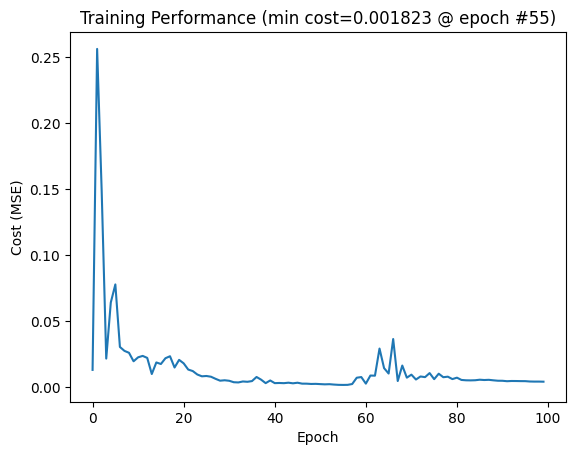

In [13]:
### Show training performance
plt.title(f'Training Performance (min cost={np.round(min_cost, 6)} @ epoch #{min_iter})')
plt.xlabel('Epoch')
plt.ylabel('Cost (MSE)')
plt.plot(hist_cost,'-')
plt.show()

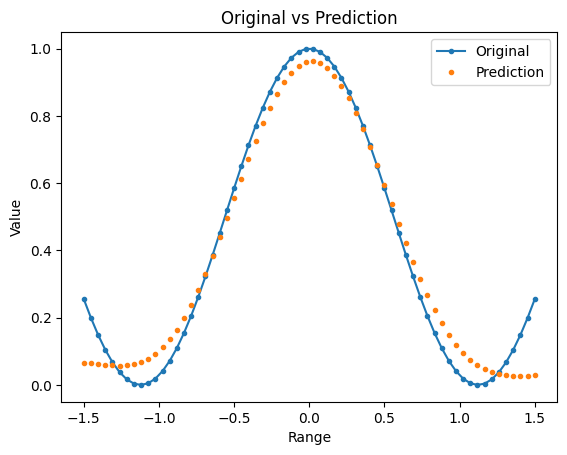

In [14]:
### Plot original vs prediction
y_pred = [qnn_model(params, x) for x in X]

plt.title('Original vs Prediction')
plt.xlabel('Range')
plt.ylabel('Value')
plt.plot(X[:,0], y, '.-', label='Original')
plt.plot(X[:,0], y_pred, '.', label='Prediction')
plt.legend(loc='best', ncol=1)
plt.show()

---

## Write your observations here

- Task 1:
- Task 2:
- Task 3:
- Task 4:
- Task 5:
- Task 6:
- Task 7:
- Challenge:
- Reflection:

## Modifications (do not remove)
Under the [GPL-3.0](https://www.gnu.org/licenses/gpl-3.0.txt) license, if you perform any changes to this notebook, please list them here, adding a note with your name, contact details, date and changes to the code.

- [Jacob Cybulski](http://jacobcybulski.com) (2025, 1 April): The author of this notebook added this section to record all code changes
- [Jacob Cybulski](http://jacobcybulski.com) (2026, 9 April): Now also compatible with...<br>
  pennylane                 0.44.1<br>
  pennylane_lightning       0.44.0<br>
  torch                     2.11.0+cpu<br>
  torchaudio                2.11.0<br>
  torchvision               0.26.0+cpu<br>
- [Jacob Cybulski](http://jacobcybulski.com) (2026, 2 Jun): Adaptation for Deakin tutorial

## Software (Linux)

In [15]:
import os
os.system('pip list | grep -e pennylane -e torch');

pennylane                 0.43.2
pennylane_lightning       0.43.0
torch                     2.6.0+cu126
torch-geometric           2.6.1
torchaudio                2.6.0+cu126
torcheval                 0.0.7
torchsummary              1.5.1
torchvision               0.21.0+cu126
